## Libraries and Packages

In [4]:
## conda env (kernel): faiss_py10

import torch
import torch.nn as nn

import faiss
import numpy as np
import albumentations as A
from albumentations.pytorch import ToTensorV2
import glob 
from tqdm import tqdm 
import matplotlib.pyplot as plt 
import os 

from torchvision.models import resnet50
from moco_loader import load_moco_backbone


import warnings
warnings.filterwarnings("ignore")

## Setup (Define Here)

### if pre-trained weight is not downloaded

In [5]:
!curl -O https://dl.fbaipublicfiles.com/moco/moco_checkpoints/moco_v2_200ep/moco_v2_200ep_pretrain.pth.tar

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100  106M  100  106M    0     0   105M      0  0:00:01  0:00:01 --:--:--  105M


In [6]:
pretrained_weight = 'moco_v2_200ep_pretrain.pth.tar'                   # Path to pre-trained checkpoint
device = torch.device("cuda:0")                                        # Specify GPU index 
path_to_all_images = '/data/guoj5/testing1/*.npy'                      # Path to all database images
number_to_retrieve = 10                                                # Top-k retrieval ranked by cosine similarity

query_image_path = '/data/guoj5/testing1/CLS1-7760-223.npy'            # A query image for retrieval


# image to embedding help func
def extract_features(image_path, model, transform):
    """Extract image features using the provided model."""
    image = np.load(image_path)
    input_tensor = transform(image=image)['image'].unsqueeze(0) # unsqueeze when batch size 1 
    
    # torch uint8 -> torch.float32
    if input_tensor.dtype == torch.uint8:
        input_tensor = input_tensor.float() / 255.0  # Convert to float and normalize

    with torch.no_grad():
        input_tensor = input_tensor.to(device)
        features = model(input_tensor)
    return features.cpu().detach().numpy().squeeze()

## Load pre-trained backbone

In [7]:
# make a ResNet-50 for 8 channels
model = resnet50(pretrained=False)   # or True if ImageNet init
model.fc = nn.Identity()   
model.conv1 = nn.Conv2d(8, 64, kernel_size=7, stride=2, padding=3, bias=False)

# load MoCo weights
model = load_moco_backbone(model, pretrained_weight, in_chans=8)

=> loading checkpoint 'moco_v2_200ep_pretrain.pth.tar'
Top-level keys: ['state_dict', 'epoch', 'arch']
Missing keys: []
Unexpected keys: []


## Create faiss index database

In [8]:
 # 1. Move the model to GPU
model = model.to(device)        


# 2. Define a Transformation Pipeline for Images
resize_transform = A.Compose([
    A.Resize(224, 224),     # Target size (H, W)
    ToTensorV2()            # Converts to PyTorch tensor
])


# 3. Create a Dataset of Image Features
image_paths = glob.glob(path_to_all_images)

features = [extract_features(img, model, resize_transform) for img in tqdm(image_paths, desc="FAISS ID CREATE:")]
features = np.array(features).astype('float32')  # Convert to float32 (required by FAISS)

# 4. Normalize the Features (Required for Cosine Similarity)
features_normalized = features / np.linalg.norm(features, axis=1, keepdims=True)

# 5. Create a FAISS Index for Inner Product (Cosine Similarity)
dimension = features_normalized.shape[1]     # Dimension of the feature vectors
index = faiss.IndexFlatIP(dimension)         # Inner product index
index.add(features_normalized)               # Add normalized features to the index

print(f"Number of images indexed: {index.ntotal}")

FAISS ID CREATE:: 100%|██████████| 8019/8019 [00:45<00:00, 176.25it/s]


Number of images indexed: 8019


## Query image

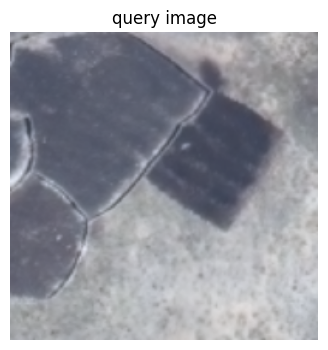

In [9]:
query_feature = extract_features(query_image_path, model, resize_transform).astype('float32')
query_feature_normalized = query_feature / np.linalg.norm(query_feature)  # Normalize query

plt.figure(figsize=(4,4))
plt.imshow(np.load(query_image_path)[:,:,(4,2,1)])
plt.axis('off')
plt.title('query image')
plt.show()

## Retrieve Top-k images from database

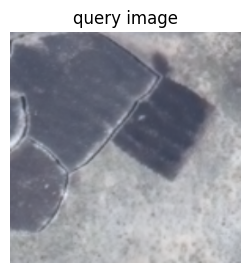

Top 10 similar images


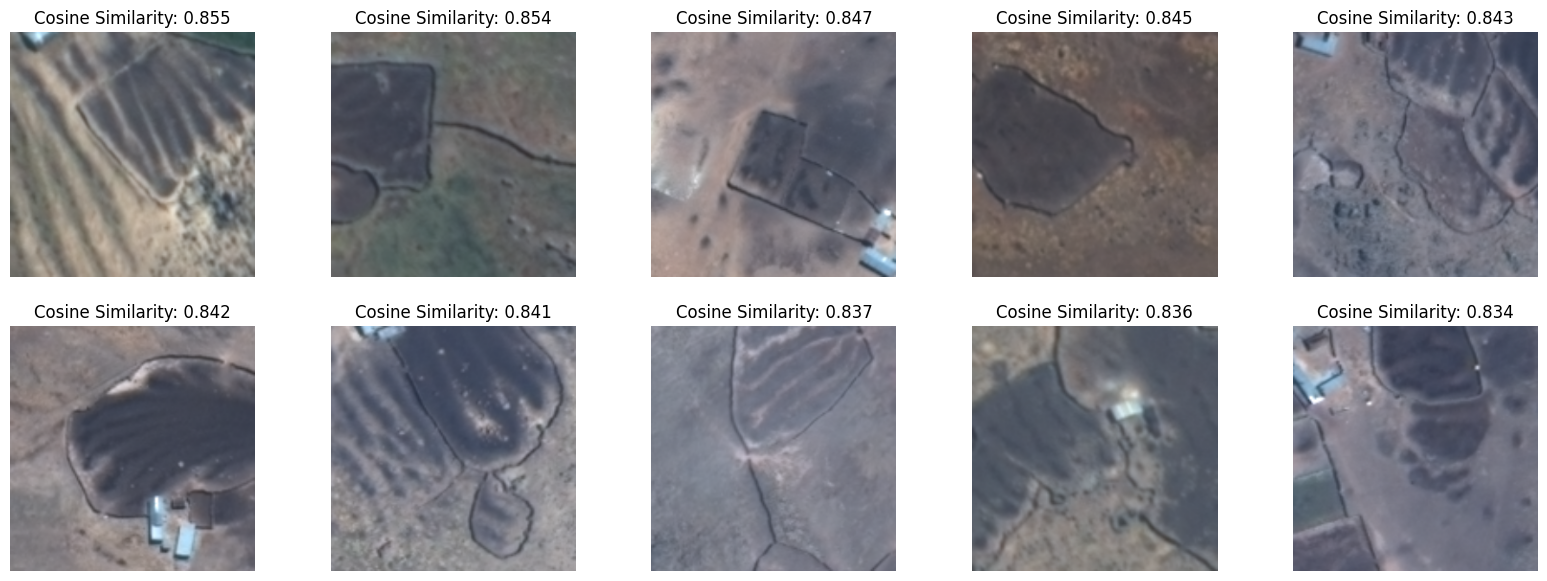

In [10]:
 #  number_to_retrieve + 1 of similar images to retrieve (including the query Image itself)
distances, indices = index.search(np.expand_dims(query_feature_normalized, axis=0), number_to_retrieve + 1)


# 7. Display Results

# dispaly query image input 
plt.figure(figsize=(3,3))
plt.imshow(np.load(query_image_path)[:,:,(4,2,1)])
plt.axis('off')
plt.title('query image')
plt.show()


# display retrieved top-k images (k =10 means number_to_retrieve = 10)
print(f'Top {number_to_retrieve} similar images')
fig, axes = plt.subplots(2, 5, figsize=(20, 7))  # Adjust col number based on k (number_to_retrieve)
count = 0 
for idx, dist in zip(indices[0][1::], distances[0][1::]):
    # Load and display the image using channels 4, 2, and 1 as RGB for visualization purposes only
    img = np.load(image_paths[idx])[:, :, (4, 2, 1)]
    axes[count//5][count % 5].imshow(img)
    axes[count//5][count % 5].set_title(f'Cosine Similarity: {dist:.3f}')
    axes[count//5][count % 5].axis('off')  
    count +=1 